In [ ]:
# House Price Prediction Using Linear Regression

## Artificial Intelligence & Machine Learning – Task 1

This project aims to build and evaluate a Linear Regression model for predicting house prices using the California Housing Dataset.

In [ ]:
## 1. Objective

The objective of this project is to introduce the complete machine learning workflow, including data loading, data exploration, preprocessing, model training, evaluation, and reporting.

A Linear Regression model is used to predict house prices based on different features available in the California Housing Dataset.

In [ ]:
## 2. Import Required Libraries

The following Python libraries are used in this project:

- NumPy for numerical operations
- Pandas for data manipulation and analysis
- Matplotlib for visualization
- Seaborn for statistical visualization
- Scikit-learn for dataset loading, model training, data splitting, and evaluation

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
## 3. Load the California Housing Dataset

The California Housing Dataset is used for this project. It contains information about different characteristics of housing areas in California.

The target variable is `MedHouseVal`, which represents the median house value.

In [3]:
housing = fetch_california_housing(as_frame=True)

df = housing.frame

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
## 4. Dataset Overview

In this section, the dataset is examined to understand its structure, number of observations, features, data types, and statistical properties.

The following operations are performed:

- Checking the shape of the dataset
- Displaying column names
- Checking data types
- Generating descriptive statistics
- Checking for missing values

In [4]:
df.shape


(20640, 9)

In [5]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [8]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [9]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [ ]:
## 5. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the distribution and relationships within the dataset.

Different statistical and graphical techniques are used to identify patterns, distributions, and relationships between the features and house prices.

In [ ]:
## 6. Data Visualization

Visualization helps in understanding the dataset more clearly.

Histograms are used to observe the distribution of the numerical variables, while scatter plots are used to examine relationships between individual features and house prices.

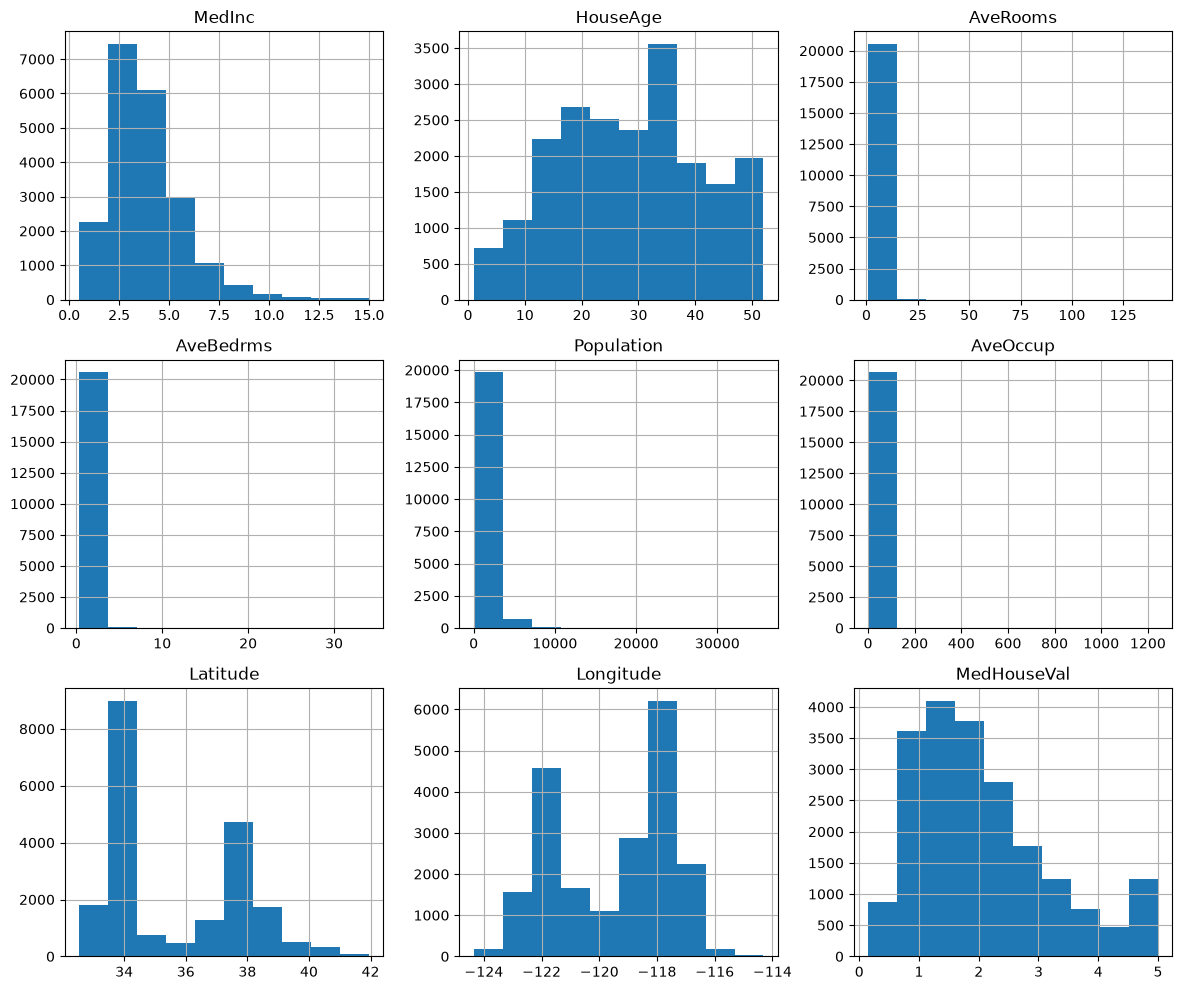

In [12]:
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

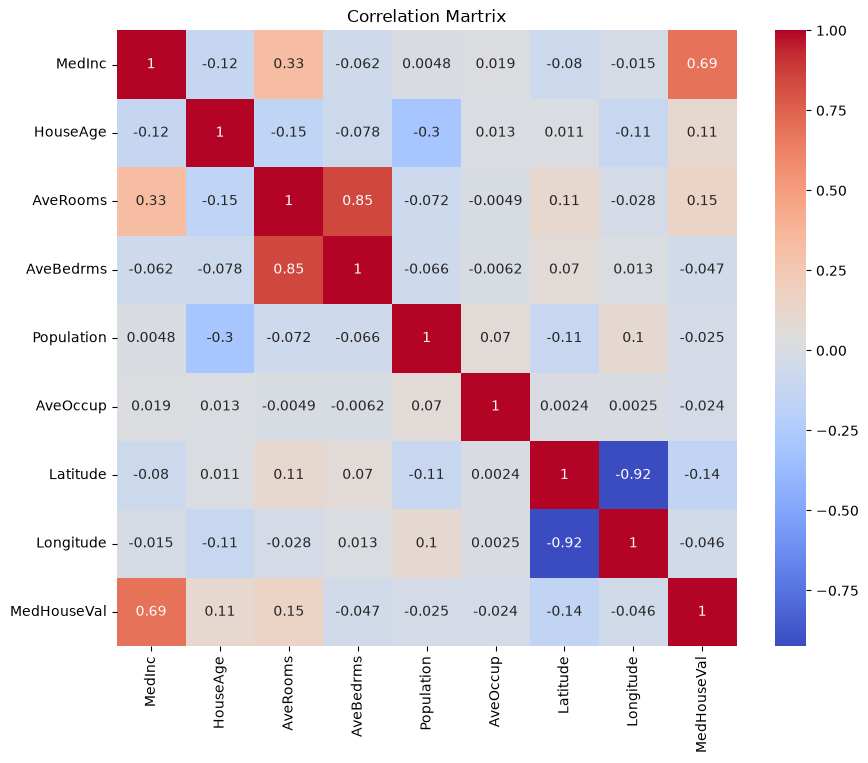

In [13]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Martrix")
plt.show()

In [ ]:
## 7. Correlation Analysis

A correlation matrix is used to examine the relationship between the numerical features.

The heatmap provides a visual representation of the correlation between variables and helps identify features that have stronger relationships with the target variable.

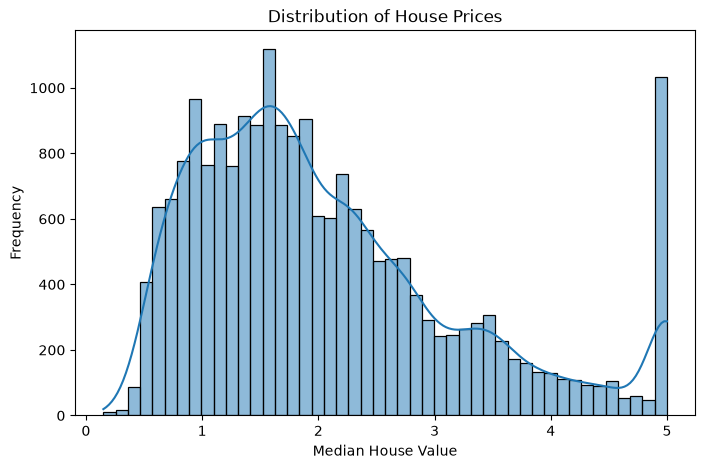

In [14]:
plt.figure(figsize=(8, 5))

sns.histplot(df["MedHouseVal"], kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Median House Value")
plt.ylabel("Frequency")

plt.show()

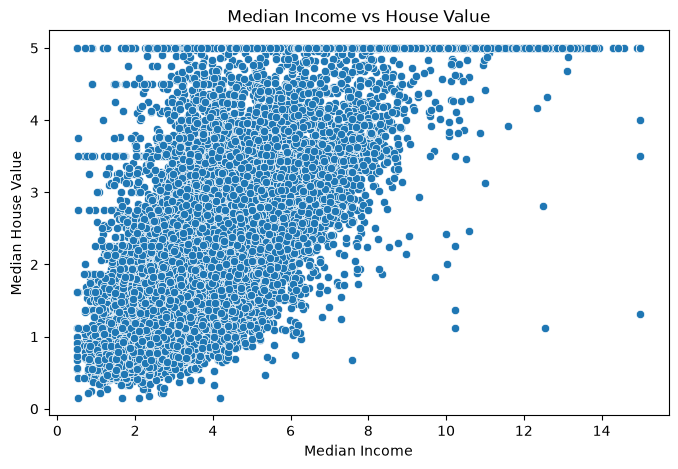

In [15]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="MedInc",
    y="MedHouseVal"
)

plt.title("Median Income vs House Value")
plt.xlabel("Median Income")
plt.ylabel("Median House Value")

plt.show()

In [ ]:
## 8. Feature and Target Selection

The dataset is divided into independent variables (features) and the dependent variable (target).

The features are used as input to the Linear Regression model, while `MedHouseVal` is selected as the target variable that the model needs to predict.

In [17]:
X = df.drop("MedHouseVal", axis=1)

y = df["MedHouseVal"]

In [18]:
print("Features:", X.shape)
print("Target:", y.shape)

Features: (20640, 8)
Target: (20640,)


In [ ]:
## 9. Train-Test Split

The dataset is divided into training and testing sets.

The training dataset is used to train the Linear Regression model, while the testing dataset is used to evaluate how well the trained model performs on unseen data.

An 80:20 split is used, where 80% of the data is used for training and 20% for testing.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (16512, 8)
Testing data: (4128, 8)


In [ ]:
## 10. Linear Regression Model

Linear Regression is a supervised machine learning algorithm used to model the relationship between a dependent variable and one or more independent variables.

In this project, Linear Regression is trained using the training dataset to predict median house values.

In [21]:
model = LinearRegression()

In [22]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 0.45, 0.01,-0.12,...,-0. ,-0.42,-0.43]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['MedInc','HouseAge','AveRooms',...,'AveOccup','Latitude','Longitude']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-37.02
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


In [ ]:
## 11. Making Predictions

After training the Linear Regression model, predictions are made using the test dataset.

The predicted values are compared with the actual house values to evaluate the performance of the model.

In [23]:
y_pred = model.predict(X_test)

In [24]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,0.47700,0.719123
1,0.45800,1.764017
2,5.00001,2.709659
3,2.18600,2.838926
4,2.78000,2.604657
5,1.58700,2.011754
6,1.98200,2.645500
7,1.57500,2.168755
8,3.40000,2.740746
9,4.46600,3.915615


In [ ]:
## 12. Model Evaluation

The performance of the Linear Regression model is evaluated using three metrics:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

These metrics help determine how accurately the model predicts house prices.

In [25]:
mae = mean_absolute_error(y_test, y_pred)

In [26]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

In [27]:
r2 = r2_score(y_test, y_pred)

In [28]:
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 0.5332001304956555
Root Mean Squared Error (RMSE): 0.7455813830127763
R² Score: 0.575787706032451


In [ ]:
## 13. Actual vs Predicted Values

The actual and predicted house values are plotted to visually evaluate the performance of the Linear Regression model.

Points closer to the reference line indicate predictions that are closer to the actual values.

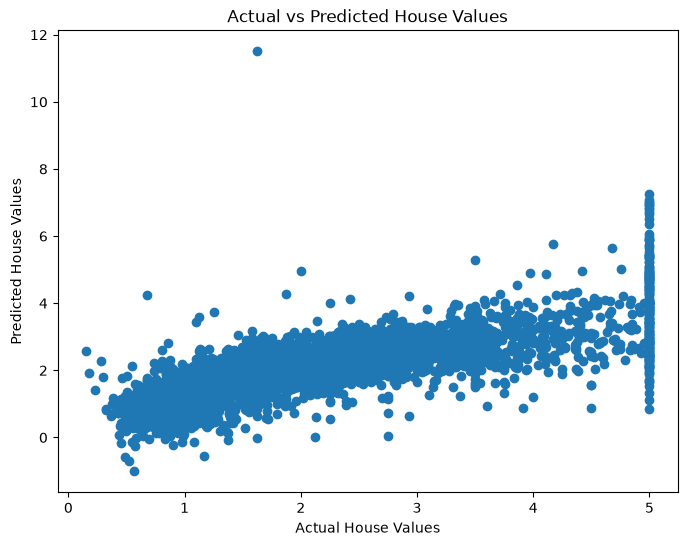

In [29]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual House Values")
plt.ylabel("Predicted House Values")
plt.title("Actual vs Predicted House Values")

plt.show()

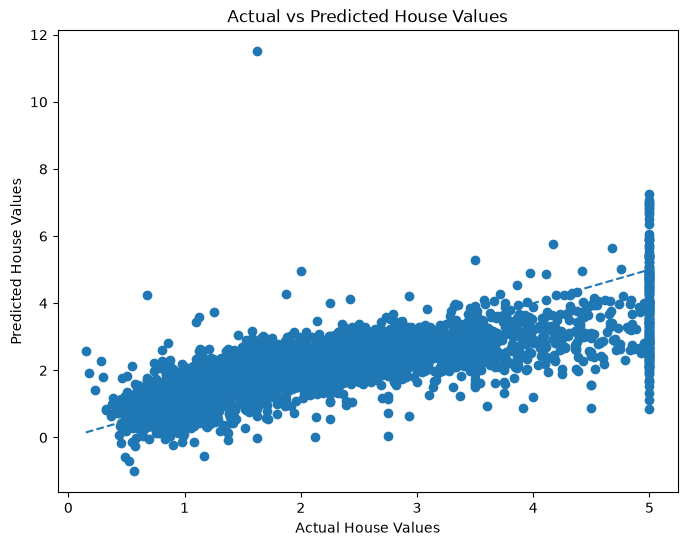

In [30]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual House Values")
plt.ylabel("Predicted House Values")
plt.title("Actual vs Predicted House Values")

plt.show()

In [ ]:
## 14. Model Coefficients

The coefficients of the Linear Regression model indicate the relationship between each input feature and the predicted house value.

Examining the coefficients helps in understanding the contribution of individual features to the model's predictions.

In [31]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,MedInc,0.448675
1,HouseAge,0.009724
2,AveRooms,-0.123323
3,AveBedrms,0.783145
4,Population,-0.000002
5,AveOccup,-0.003526
6,Latitude,-0.419792
7,Longitude,-0.433708


In [32]:
coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
3,AveBedrms,0.783145
0,MedInc,0.448675
1,HouseAge,0.009724
4,Population,-0.000002
5,AveOccup,-0.003526
2,AveRooms,-0.123323
6,Latitude,-0.419792
7,Longitude,-0.433708


In [33]:
print("Intercept:", model.intercept_)

Intercept: -37.02327770606416


In [ ]:
## 15. Results

The Linear Regression model was successfully trained and evaluated on the California Housing Dataset.

The model performance is measured using MAE, RMSE, and R² Score. The obtained values provide an indication of the prediction accuracy of the model.

In [34]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.


In [35]:
import joblib

joblib.dump(model, "linear_regression_model.pkl")

['linear_regression_model.pkl']

In [ ]:
## 16. Improvement Ideas

The performance of the model can potentially be improved by:

- Performing additional feature engineering
- Trying other regression algorithms
- Using Ridge or Lasso Regression
- Using Random Forest Regression
- Using Gradient Boosting methods
- Performing hyperparameter tuning

In [ ]:
## 17. Conclusion

In this project, a complete machine learning workflow was implemented for house price prediction using the California Housing Dataset.

The data was explored and visualized, divided into training and testing sets, and used to train a Linear Regression model. The trained model was then evaluated using MAE, RMSE, and R² Score.

This project provided practical experience with data loading, exploratory data analysis, model training, prediction, evaluation, and reporting.